# Combined Chromatin Deconvolution Run
March 7, 2024

Trial combined chromatin deconvolution model run

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [69]:
from src.config import load_yl_rg1_vst_config
from cc_src.combined_chromatin_model import CombinedChromatinModel

config1 = load_yl_rg1_vst_config(1)
config2 = load_yl_rg1_vst_config(2)
combined_model = CombinedChromatinModel(config1, config2)


In [70]:
gene_name = "CLB2"
combined_model.load_combined_mnase_gene(gene_name)

Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.
Loading MNase reads for YCR073C/SSK22...Loading chromosome reads: 3
Done.


In [71]:
# Deconvolve
combined_model.deconvolve(verbose=True)

Deconvolving combined model with gamma=0.006, gamma_prime=0
                                     CVXPY                                     
                                     v1.4.1                                    
(CVXPY) Mar 07 04:32:25 PM: Your problem has 181600 variables, 1 constraints, and 1 parameters.
(CVXPY) Mar 07 04:32:25 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 07 04:32:25 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 07 04:32:25 PM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) Mar 07 04:32:25 PM: Compiling problem (target solver=MOSEK).
(CVXPY) Mar 07 04:32:25 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr

(CVXPY) Mar 07 04:33:52 PM: 25  1.2e-02  2.5e-02  1.4e-03  4.86e-01   8.008979171e+03   8.008984725e+03   1.2e-02  29.65 
(CVXPY) Mar 07 04:33:52 PM: 26  1.1e-02  2.2e-02  1.2e-03  4.67e-01   7.998214145e+03   7.998219265e+03   1.1e-02  30.05 
(CVXPY) Mar 07 04:33:52 PM: 27  9.4e-03  1.9e-02  9.7e-04  4.46e-01   7.986610463e+03   7.986615147e+03   9.4e-03  30.43 
(CVXPY) Mar 07 04:33:53 PM: 28  8.3e-03  1.7e-02  8.3e-04  4.31e-01   7.976484324e+03   7.976488668e+03   8.3e-03  30.80 
(CVXPY) Mar 07 04:33:53 PM: 29  7.1e-03  1.4e-02  6.9e-04  4.21e-01   7.964107193e+03   7.964111151e+03   7.1e-03  31.17 
(CVXPY) Mar 07 04:33:53 PM: 30  6.1e-03  1.2e-02  5.7e-04  4.13e-01   7.951719392e+03   7.951722998e+03   6.1e-03  31.55 
(CVXPY) Mar 07 04:33:54 PM: 31  5.4e-03  1.1e-02  4.8e-04  4.09e-01   7.941225279e+03   7.941228608e+03   5.4e-03  31.94 
(CVXPY) Mar 07 04:33:54 PM: 32  5.3e-03  1.1e-02  4.6e-04  4.08e-01   7.938942103e+03   7.938945376e+03   5.3e-03  32.31 
(CVXPY) Mar 07 04:33:55 

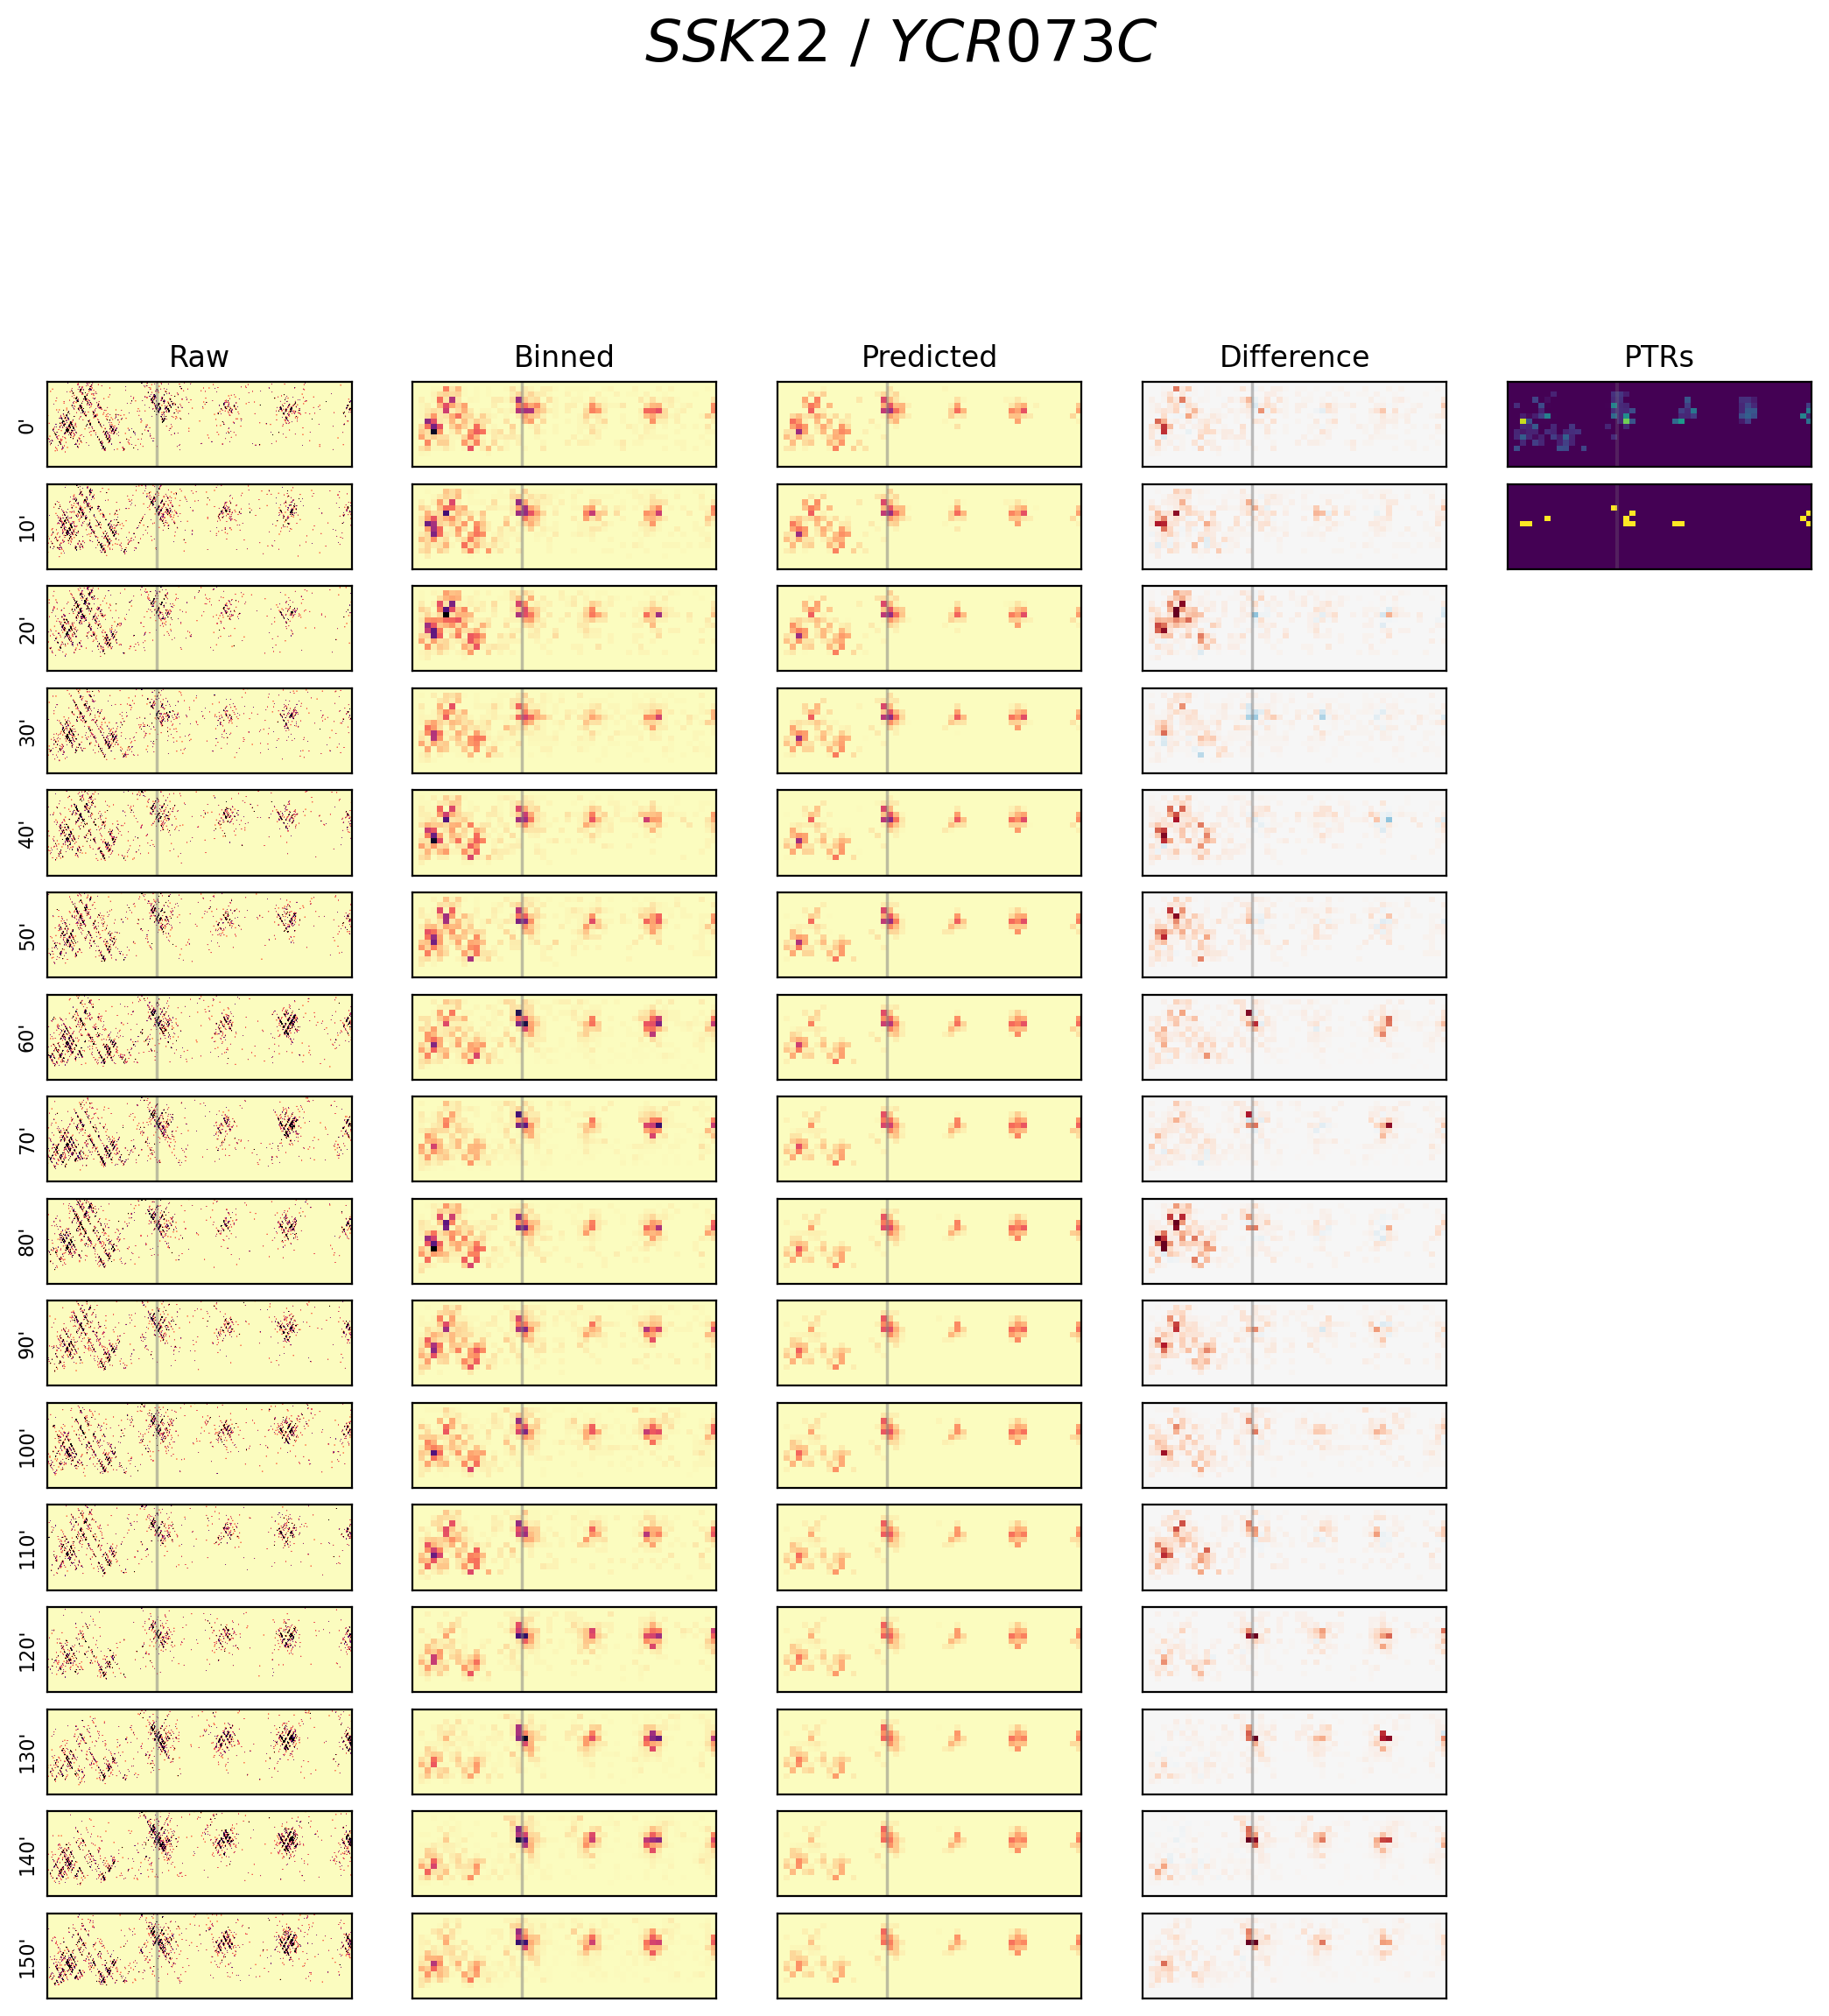

In [72]:
fig = combined_model.plot_raw_prediction(1, vmax=50)

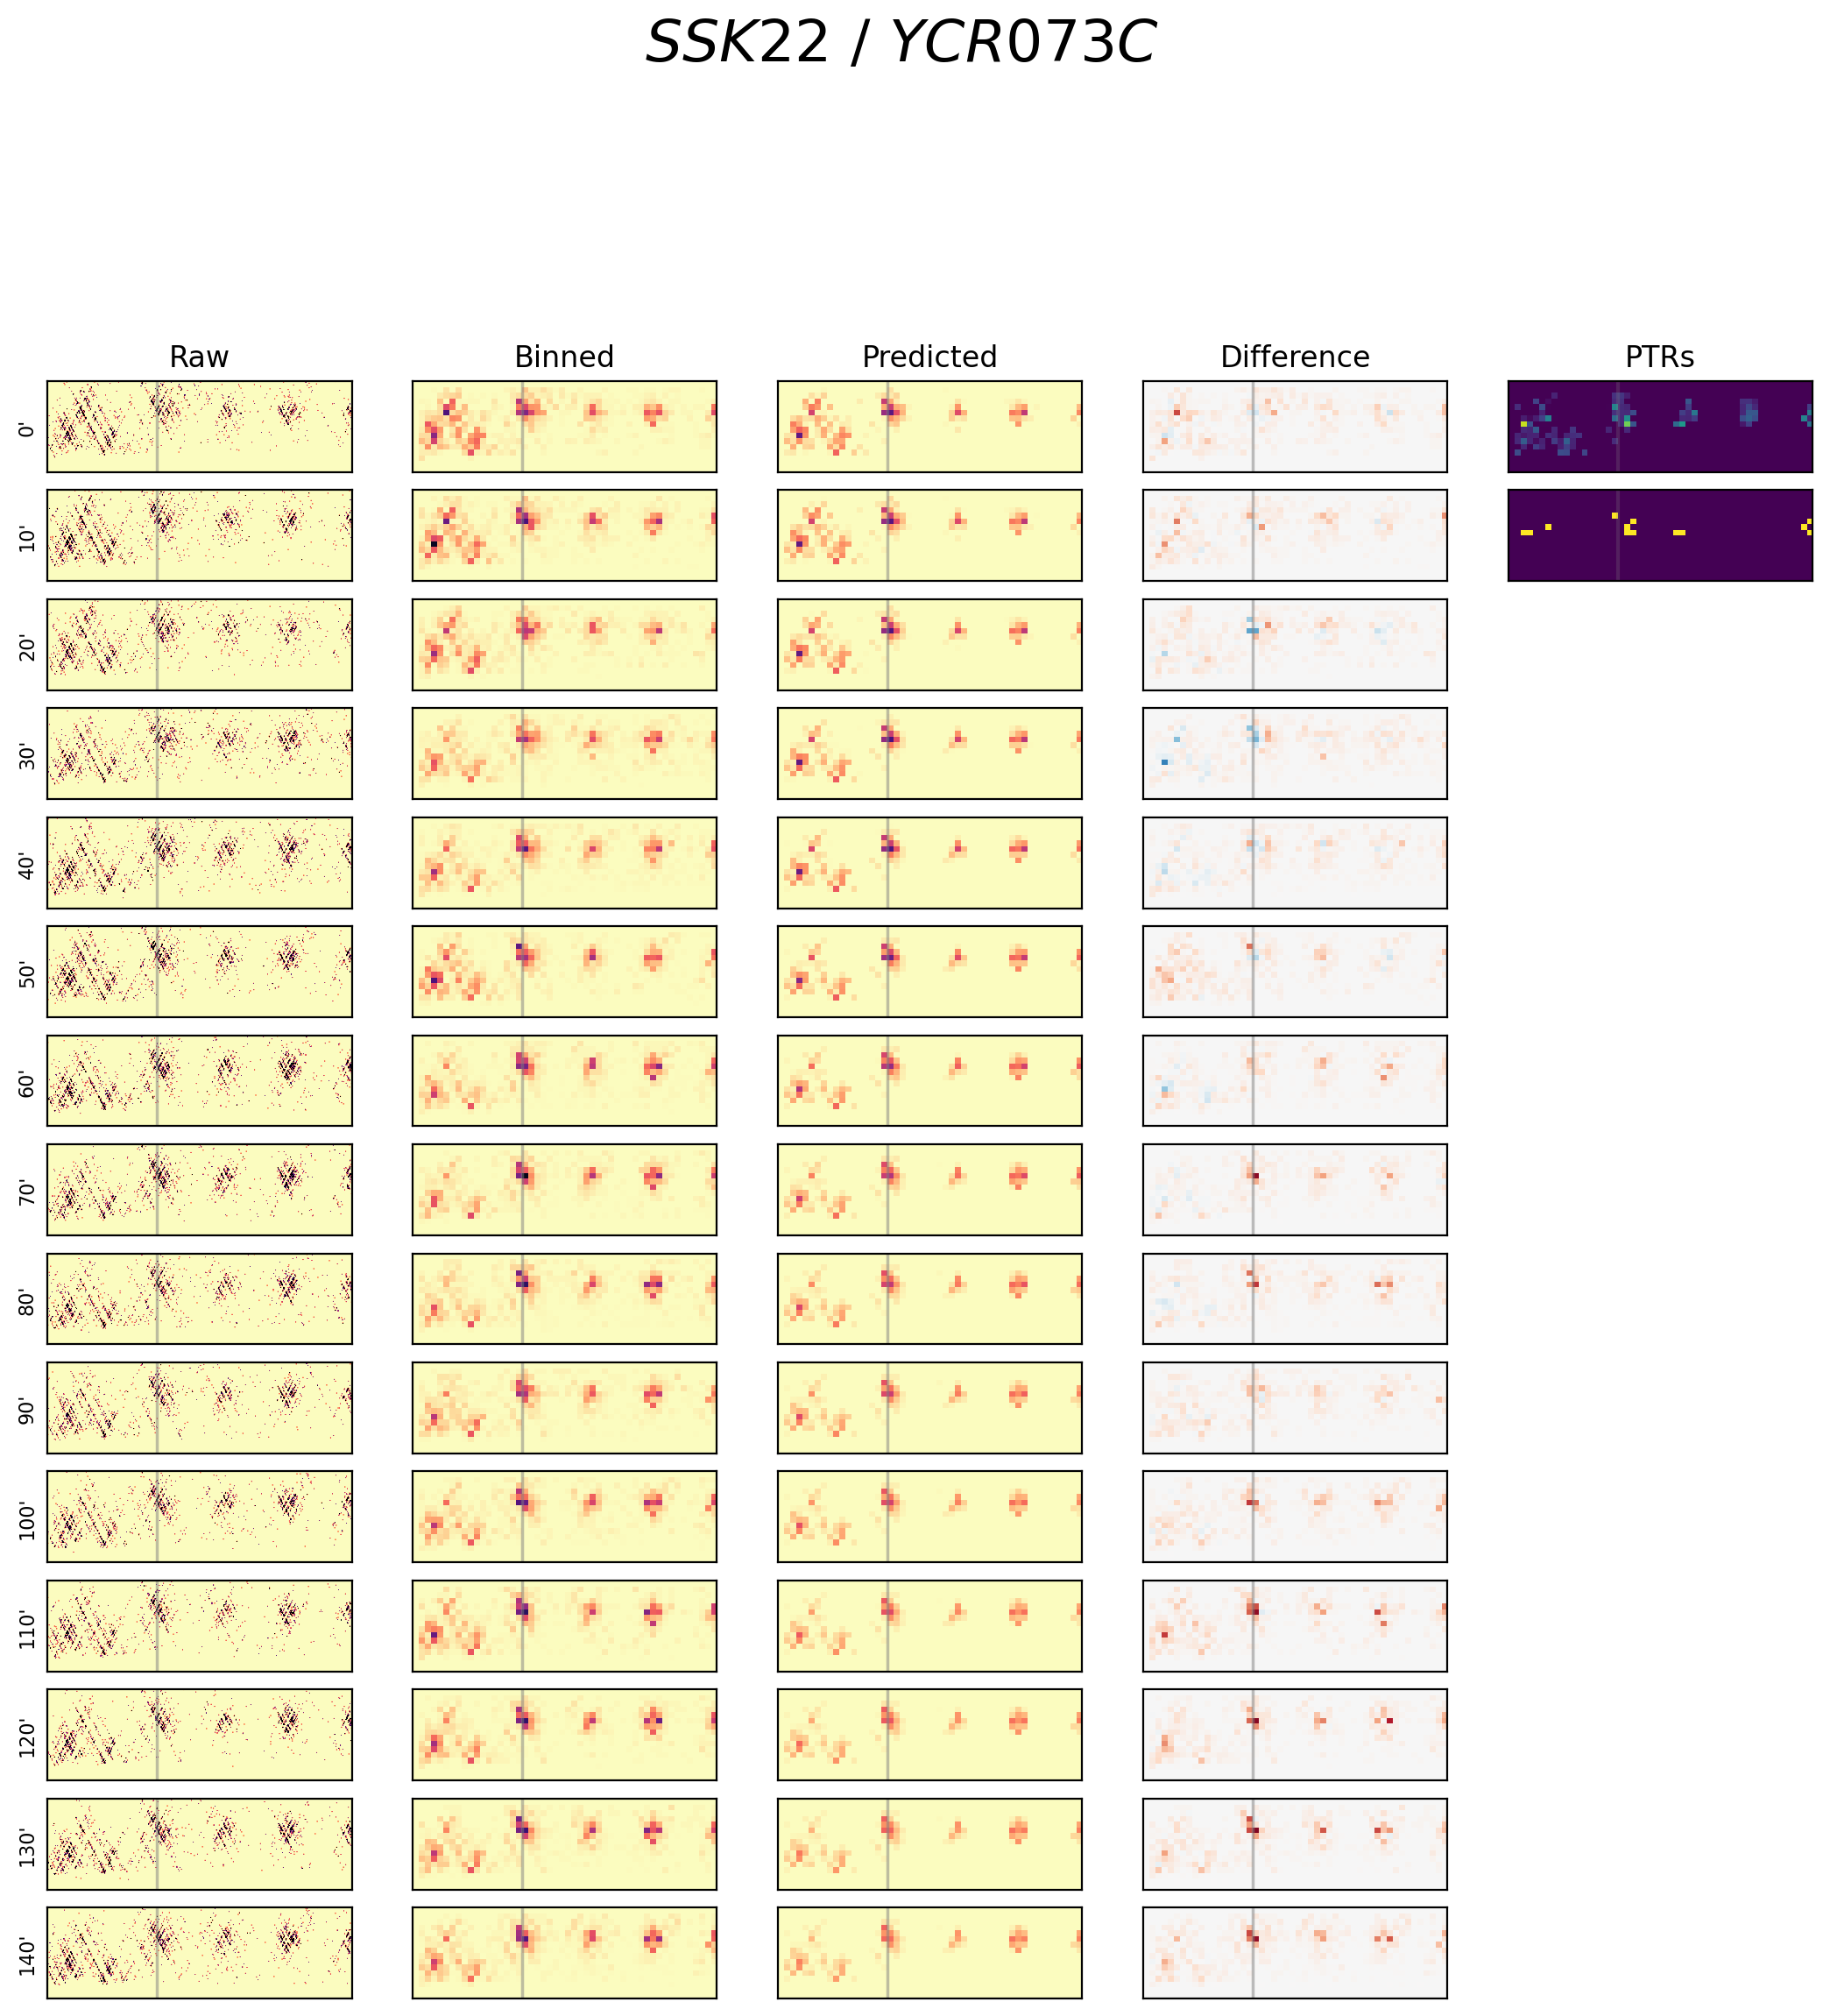

In [73]:
fig = combined_model.plot_raw_prediction(2, vmax=50)

In [74]:
# Deconvolve the combined gene expression model
from src.config import load_combined_yl_alpha_vst_gene_expression_config
from src.model import Model

combined_ge_config = load_combined_yl_alpha_vst_gene_expression_config()
ge_model = Model(combined_ge_config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

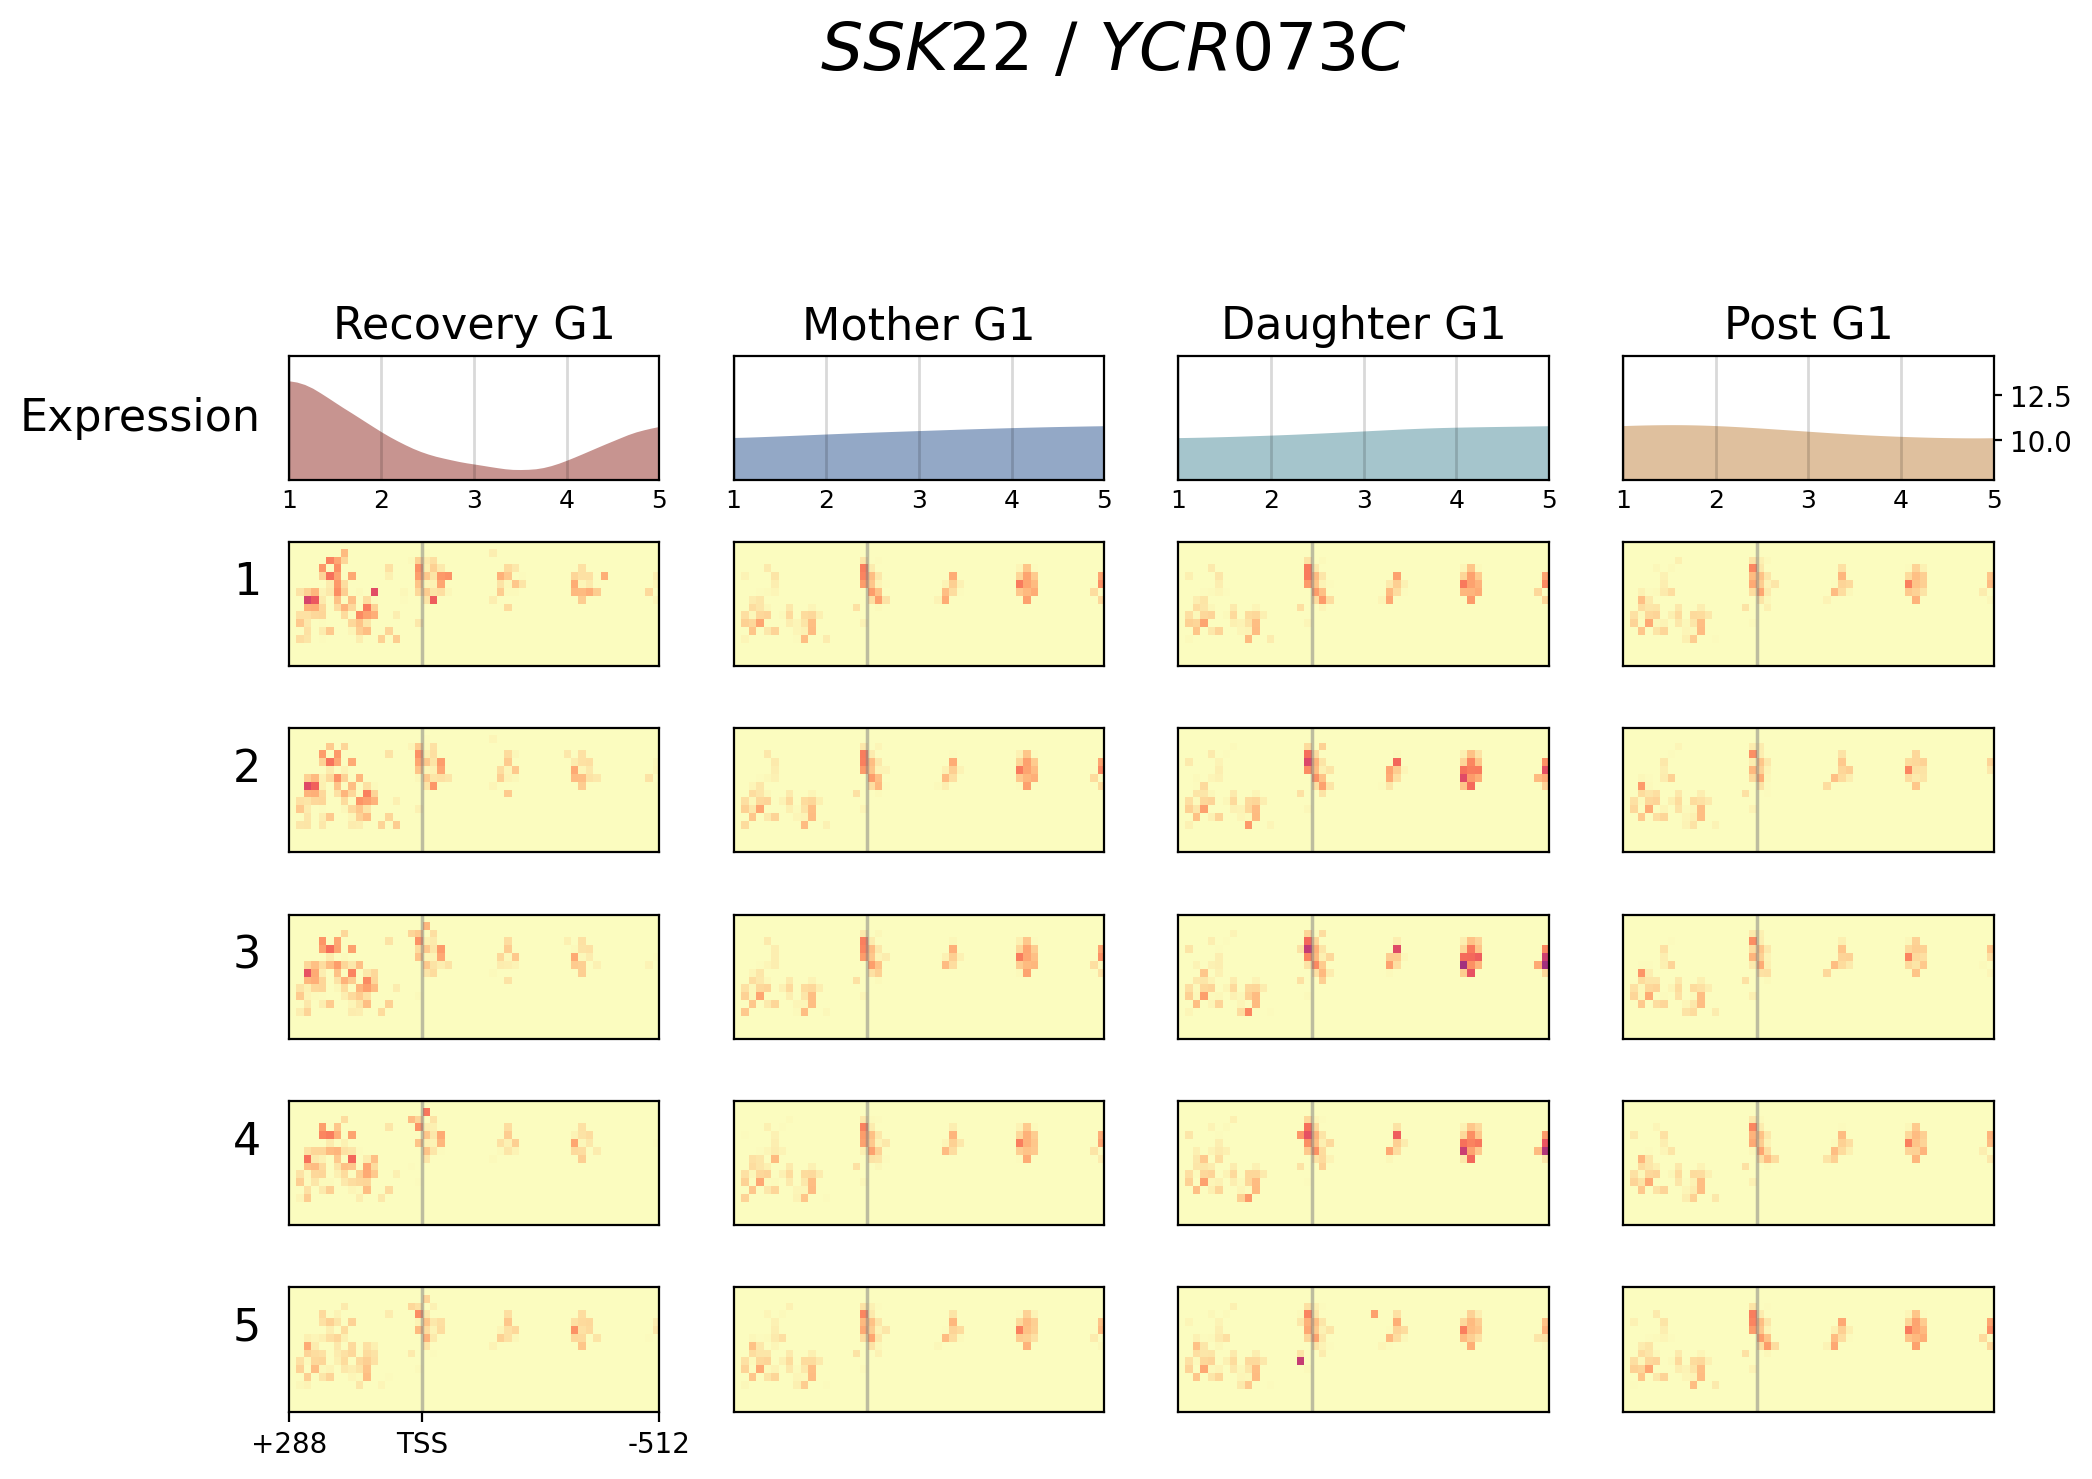

In [75]:
fig = combined_model.create_deconvolution_plots_abbreviated_flipped(vmax=50, ge_model=ge_model)